### Set up
Run one by one

# What does this notebook do?
- generate metadata, including:
  - the title of document
  - filname
  - text embedding
  - image (table) embedding
- turn the embedding into FAISS file


For scaling up: pinecone



## Setup

In [ ]:
# @title Install packages
! pip3 install --upgrade --user google-cloud-aiplatform
! pip install rich

In [ ]:
# Restart kernel after installs so that your environment can access the new packages
import IPython
import time

app = IPython.Application.instance()
app.kernel.do_shutdown(True)

In [ ]:
### Authenticate your notebook environment (Colab only)
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()

## Optional - run if host files in Cloud

In [ ]:
# Define project information
import vertexai

import sys

PROJECT_ID = "salesforce-assistant" # @param {type:"string"}
LOCATION = "us-central1"  # @param {type:"string"}
BUCKET_NAME = "salesforce-assistant"
text_data_path = f"gs://salesforce-assistant/texts/"
table_data_path = f"gs://salesforce-assistant/tables/"
image_data_path = f"gs://salesforce-assistant/images/"

# if not running on colab, try to get the PROJECT_ID automatically
if "google.colab" not in sys.modules:
    import subprocess

    PROJECT_ID = subprocess.check_output(
        ["gcloud", "config", "get-value", "project"], text=True
    ).strip()

print(f"Your project ID is: {PROJECT_ID}")
vertexai.init(project=PROJECT_ID, location=LOCATION)

In [ ]:
!gcloud config set project salesforce-assistant

## run if host files in Google colab


In [ ]:
# @title make data folder if it doesn't exist
data_folder = "/content/drive/MyDrive/data"  # You can change the path if needed
os.makedirs(data_folder, exist_ok=True)

## Generate embeddings

In [ ]:
# @title import AI related dependency

from rich import print as rich_print
from rich.markdown import Markdown as rich_Markdown
from IPython.display import Markdown, display
from vertexai.generative_models import (
    Content,
    GenerationConfig,
    GenerationResponse,
    GenerativeModel,
    HarmCategory,
    HarmBlockThreshold,
    Image,
    Part,
)
from vertexai.language_models import TextEmbeddingModel
from vertexai.vision_models import MultiModalEmbeddingModel

# Multimodal models: Choose based on your performance/cost needs

multimodal_model_2_0_flash = GenerativeModel(
    "gemini-2.0-flash-001"
) # Gemini latest Gemini 2.0 Flash Model

multimodal_model_15 = GenerativeModel(
    "gemini-1.5-pro-001"
)  # works with text, code, images, video(with or without audio) and audio(mp3) with 1M input context - complex reasoning

# Multimodal models: Choose based on your performance/cost needs
multimodal_model_15_flash = GenerativeModel(
    "gemini-1.5-flash-001"
)  # works with text, code, images, video(with or without audio) and audio(mp3) with 1M input context - faster inference

# Load text embedding model from pre-trained source
text_embedding_model = TextEmbeddingModel.from_pretrained("text-embedding-005")

# Load multimodal embedding model from pre-trained source
multimodal_embedding_model = MultiModalEmbeddingModel.from_pretrained(
    "multimodalembedding@001"
)  # works with image, image with caption(~32 words), video, video with caption(~32 words)

In [ ]:
# @title create a "data" folder and "image" folder

import os

# Create the "data" folder if it doesn't exist
data_folder = "data"
if not os.path.exists(data_folder):
  os.makedirs(data_folder)

# Create the "image" folder if it doesn't exist
image_folder = "images"
if not os.path.exists(image_folder):
  os.makedirs(image_folder)

In [ ]:
# @title Test on one file (download from cloud bucket, or upload your own)
from google.cloud import storage

BUCKET_NAME = "ifad-lanzi"
FILE_NAME = "Djibouti 2000002545 PGIRE Project Design Report September 2020 Fr.pdf"

client = storage.Client()
bucket = client.bucket(BUCKET_NAME)
blob = bucket.blob(FILE_NAME)

LOCAL_FILE_PATH = "/content/data/" + FILE_NAME
blob.download_to_filename(LOCAL_FILE_PATH)

print(f"✅ File downloaded successfully: {LOCAL_FILE_PATH}")
print("Download completed")

In [ ]:
# Helper function
#@title Helper Functions

import glob
import os
import time
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union

from IPython.display import display
import PIL
import fitz
import numpy as np
import pandas as pd
import requests
from pathlib import Path
from vertexai.generative_models import (
    GenerationConfig,
    HarmBlockThreshold,
    HarmCategory,
    Image,
)
from vertexai.vision_models import Image as vision_model_Image

# function to set embeddings as global variable

def set_global_variable(variable_name: str, value: any) -> None:
    """
    Sets the value of a global variable.

    Args:
        variable_name: The name of the global variable (as a string).
        value: The value to assign to the global variable. This can be of any type.
    """
    global_vars = globals()  # Get a dictionary of global variables
    global_vars[variable_name] = value



# Functions for getting text and image embeddings

def get_text_embedding_from_text_embedding_model(
    text: str,
    return_array: Optional[bool] = False,
) -> list:
    """
    Generates a numerical text embedding from a provided text input using a text embedding model.

    Args:
        text: The input text string to be embedded.
        return_array: If True, returns the embedding as a NumPy array.
                      If False, returns the embedding as a list. (Default: False)

    Returns:
        list or numpy.ndarray: A 768-dimensional vector representation of the input text.
                               The format (list or NumPy array) depends on the
                               value of the 'return_array' parameter.
    """
    embeddings = text_embedding_model.get_embeddings([text])
    text_embedding = [embedding.values for embedding in embeddings][0]

    if return_array:
        text_embedding = np.fromiter(text_embedding, dtype=float)

    # returns 768 dimensional array
    return text_embedding


def get_image_embedding_from_multimodal_embedding_model(
    image_uri: str,
    embedding_size: int = 512,
    text: Optional[str] = None,
    return_array: Optional[bool] = False,
) -> list:
    """Extracts an image embedding from a multimodal embedding model.
    The function can optionally utilize contextual text to refine the embedding.

    Args:
        image_uri (str): The URI (Uniform Resource Identifier) of the image to process.
        text (Optional[str]): Optional contextual text to guide the embedding generation. Defaults to "".
        embedding_size (int): The desired dimensionality of the output embedding. Defaults to 512.
        return_array (Optional[bool]): If True, returns the embedding as a NumPy array.
        Otherwise, returns a list. Defaults to False.

    Returns:
        list: A list containing the image embedding values. If `return_array` is True, returns a NumPy array instead.
    """
    # image = Image.load_from_file(image_uri)
    image = vision_model_Image.load_from_file(image_uri)
    embeddings = multimodal_embedding_model.get_embeddings(
        image=image, contextual_text=text, dimension=embedding_size
    )  # 128, 256, 512, 1408
    image_embedding = embeddings.image_embedding

    if return_array:
        image_embedding = np.fromiter(image_embedding, dtype=float)

    return image_embedding


def load_image_bytes(image_path):
    """Loads an image from a URL or local file path.

    Args:
        image_uri (str): URL or local file path to the image.

    Raises:
        ValueError: If `image_uri` is not provided.

    Returns:
        bytes: Image bytes.
    """
    # Check if the image_uri is provided
    if not image_path:
        raise ValueError("image_uri must be provided.")

    # Load the image from a weblink
    if image_path.startswith("http://") or image_path.startswith("https://"):
        response = requests.get(image_path, stream=True)
        if response.status_code == 200:
            return response.content

    # Load the image from a local path
    else:
        return open(image_path, "rb").read()


def get_pdf_doc_object(pdf_path: str) -> tuple[fitz.Document, int]:
    """
    Opens a PDF file using fitz.open() and returns the PDF document object and the number of pages.

    Args:
        pdf_path: The path to the PDF file.

    Returns:
        A tuple containing the `fitz.Document` object and the number of pages in the PDF.

    Raises:
        FileNotFoundError: If the provided PDF path is invalid.

    """

    # Open the PDF file
    doc: fitz.Document = fitz.open(pdf_path)

    # Get the number of pages in the PDF file
    num_pages: int = len(doc)

    return doc, num_pages


# Add colors to the print
class Color:
    """
    This class defines a set of color codes that can be used to print text in different colors.
    This will be used later to print citations and results to make outputs more readable.
    """

    PURPLE: str = "\033[95m"
    CYAN: str = "\033[96m"
    DARKCYAN: str = "\033[36m"
    BLUE: str = "\033[94m"
    GREEN: str = "\033[92m"
    YELLOW: str = "\033[93m"
    RED: str = "\033[91m"
    BOLD: str = "\033[1m"
    UNDERLINE: str = "\033[4m"
    END: str = "\033[0m"


def get_text_overlapping_chunk(
    text: str, character_limit: int = 1000, overlap: int = 100
) -> dict:
    """
    * Breaks a text document into chunks of a specified size, with an overlap between chunks to preserve context.
    * Takes a text document, character limit per chunk, and overlap between chunks as input.
    * Returns a dictionary where the keys are chunk numbers and the values are the corresponding text chunks.

    Args:
        text: The text document to be chunked.
        character_limit: Maximum characters per chunk (defaults to 1000).
        overlap: Number of overlapping characters between chunks (defaults to 100).

    Returns:
        A dictionary where keys are chunk numbers and values are the corresponding text chunks.

    Raises:
        ValueError: If `overlap` is greater than `character_limit`.

    """

    if overlap > character_limit:
        raise ValueError("Overlap cannot be larger than character limit.")

    # Initialize variables
    chunk_number = 1
    chunked_text_dict = {}

    # Iterate over text with the given limit and overlap
    for i in range(0, len(text), character_limit - overlap):
        end_index = min(i + character_limit, len(text))
        chunk = text[i:end_index]

        # Encode and decode for consistent encoding
        chunked_text_dict[chunk_number] = chunk.encode("ascii", "ignore").decode(
            "utf-8", "ignore"
        )

        # Increment chunk number
        chunk_number += 1

    return chunked_text_dict


def get_page_text_embedding(text_data: Union[dict, str]) -> dict:
    """
    * Generates embeddings for each text chunk using a specified embedding model.
    * Takes a dictionary of text chunks and an embedding size as input.
    * Returns a dictionary where the keys are chunk numbers and the values are the corresponding embeddings.

    Args:
        text_data: Either a dictionary of pre-chunked text or the entire page text.
        embedding_size: Size of the embedding vector (defaults to 128).

    Returns:
        A dictionary where keys are chunk numbers or "text_embedding" and values are the corresponding embeddings.

    """

    embeddings_dict = {}

    if not text_data:
        return embeddings_dict

    if isinstance(text_data, dict):
        # Process each chunk
        # print(text_data)
        for chunk_number, chunk_value in text_data.items():
            text_embd = get_text_embedding_from_text_embedding_model(text=chunk_value)
            embeddings_dict[chunk_number] = text_embd
    else:
        # Process the first 1000 characters of the page text
        text_embd = get_text_embedding_from_text_embedding_model(text=text_data)
        embeddings_dict["text_embedding"] = text_embd

    return embeddings_dict


def get_chunk_text_metadata(
    page: fitz.Page,
    character_limit: int = 1000,
    overlap: int = 100,
    embedding_size: int = 128,
) -> tuple[str, dict, dict, dict]:
    """
    * Extracts text from a given page object, chunks it, and generates embeddings for each chunk.
    * Takes a page object, character limit per chunk, overlap between chunks, and embedding size as input.
    * Returns the extracted text, the chunked text dictionary, and the chunk embeddings dictionary.

    Args:
        page: The fitz.Page object to process.
        character_limit: Maximum characters per chunk (defaults to 1000).
        overlap: Number of overlapping characters between chunks (defaults to 100).
        embedding_size: Size of the embedding vector (defaults to 128).

    Returns:
        A tuple containing:
            - Extracted page text as a string.
            - Dictionary of embeddings for the entire page text (key="text_embedding").
            - Dictionary of chunked text (key=chunk number, value=text chunk).
            - Dictionary of embeddings for each chunk (key=chunk number, value=embedding).

    Raises:
        ValueError: If `overlap` is greater than `character_limit`.

    """

    if overlap > character_limit:
        raise ValueError("Overlap cannot be larger than character limit.")

    # Extract text from the page
    text: str = page.get_text().encode("ascii", "ignore").decode("utf-8", "ignore")

    # Get whole-page text embeddings
    page_text_embeddings_dict: dict = get_page_text_embedding(text)

    # Chunk the text with the given limit and overlap
    chunked_text_dict: dict = get_text_overlapping_chunk(text, character_limit, overlap)
    # print(chunked_text_dict)

    # Get embeddings for the chunks
    chunk_embeddings_dict: dict = get_page_text_embedding(chunked_text_dict)
    # print(chunk_embeddings_dict)

    # Return all extracted data
    return text, page_text_embeddings_dict, chunked_text_dict, chunk_embeddings_dict



def get_image_for_gemini(
    doc: fitz.Document,
    image: tuple,
    image_no: int,
    image_save_dir: str,
    file_name: str,
    page_num: int,
):
    """
    Extracts an image from a PDF document, ensures it is in a compatible format (removes alpha & CMYK issues),
    saves it as PNG, and loads it as a PIL Image Object.
    Returns (None, None) if the image cannot be processed.
    """
    xref = image[0]

    try:
        # Wrap Pixmap creation in try/except to catch bad colorspace
        pix = fitz.Pixmap(doc, xref)

        # Skip images with missing or unsupported colorspace
        if pix.colorspace is None:
            print(f"⚠️ Skipping image {image_no} on page {page_num} in file {file_name}: colorspace is None")
            return None, None

        # Convert images with alpha (RGBA) or unsupported color spaces to RGB
        if pix.alpha:
            pix = fitz.Pixmap(fitz.csRGB, pix)  # Converts RGBA to RGB (removes transparency)
        elif pix.colorspace.n > 3:  # CMYK or other non-RGB colorspaces
            pix = fitz.Pixmap(fitz.csRGB, pix)

        # Ensure output directory exists
        os.makedirs(image_save_dir, exist_ok=True)

        # Save as PNG
        image_name = f"{image_save_dir}/{file_name}_image_{page_num}_{image_no}_{xref}.png"
        pix.save(image_name)

        image_for_gemini = Image.load_from_file(image_name)  # Load back for processing
        return image_for_gemini, image_name

    except Exception as e:
        print(f"⚠️ Skipping image {image_no} on page {page_num} in file {file_name}: {e}")
        return None, None






def get_gemini_response(
    generative_multimodal_model,
    model_input: List[str],
    stream: bool = True,
    generation_config: Optional[GenerationConfig] = GenerationConfig(
        temperature=0.2, max_output_tokens=2048
    ),
    safety_settings: Optional[dict] = {
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    },
    print_exception: bool = False,
) -> str:
    """
    This function generates text in response to a list of model inputs.

    Args:
        model_input: A list of strings representing the inputs to the model.
        stream: Whether to generate the response in a streaming fashion (returning chunks of text at a time) or all at once. Defaults to False.

    Returns:
        The generated text as a string.
    """
    response = generative_multimodal_model.generate_content(
        model_input,
        generation_config=generation_config,
        stream=stream,
        safety_settings=safety_settings,
    )
    response_list = []

    for chunk in response:
        try:
            response_list.append(chunk.text)
        except Exception as e:
            if print_exception:
              print(
                  "Exception occurred while calling gemini. Something is blocked. Lower the safety thresholds [safety_settings: BLOCK_NONE ] if not already done. -----",
                  e,
              )
            else:
              print("Exception occurred while calling gemini. Something is blocked. Lower the safety thresholds [safety_settings: BLOCK_NONE ] if not already done. -----")
            response_list.append("**Something blocked.**")
            continue
    response = "".join(response_list)

    return response


def get_text_metadata_df(
    filename: str, text_metadata: Dict[Union[int, str], Dict]
) -> pd.DataFrame:
    """
    This function takes a filename and a text metadata dictionary as input,
    iterates over the text metadata dictionary and extracts the text, chunk text,
    and chunk embeddings for each page, creates a Pandas DataFrame with the
    extracted data, and returns it.

    Args:
        filename: The filename of the document.
        text_metadata: A dictionary containing the text metadata for each page.

    Returns:
        A Pandas DataFrame with the extracted text, chunk text, and chunk embeddings for each page.
    """

    final_data_text: List[Dict] = []

    for key, values in text_metadata.items():
        for chunk_number, chunk_text in values["chunked_text_dict"].items():
            data: Dict = {}
            data["file_name"] = filename
            data["page_num"] = int(key) + 1
            data["text"] = values["text"]
            data["text_embedding_page"] = values["page_text_embeddings"][
                "text_embedding"
            ]
            data["chunk_number"] = chunk_number
            data["chunk_text"] = chunk_text
            data["text_embedding_chunk"] = values["chunk_embeddings_dict"][chunk_number]

            final_data_text.append(data)

    return_df = pd.DataFrame(final_data_text)
    return_df = return_df.reset_index(drop=True)
    return return_df


def get_image_metadata_df(
    filename: str, image_metadata: Dict[Union[int, str], Dict]
) -> pd.DataFrame:
    """
    This function takes a filename and an image metadata dictionary as input,
    iterates over the image metadata dictionary and extracts the image path,
    image description, and image embeddings for each image, creates a Pandas
    DataFrame with the extracted data, and returns it.

    Args:
        filename: The filename of the document.
        image_metadata: A dictionary containing the image metadata for each page.

    Returns:
        A Pandas DataFrame with the extracted image path, image description, and image embeddings for each image.
    """

    final_data_image: List[Dict] = []
    for key, values in image_metadata.items():
        for _, image_values in values.items():
            data: Dict = {}
            data["file_name"] = filename
            data["page_num"] = int(key) + 1
            data["img_num"] = int(image_values["img_num"])
            data["img_path"] = image_values["img_path"]
            data["img_desc"] = image_values["img_desc"]
            # data["mm_embedding_from_text_desc_and_img"] = image_values[
            #     "mm_embedding_from_text_desc_and_img"
            # ]
            data["mm_embedding_from_img_only"] = image_values[
                "mm_embedding_from_img_only"
            ]
            data["text_embedding_from_image_description"] = image_values[
                "text_embedding_from_image_description"
            ]
            final_data_image.append(data)

    return_df = pd.DataFrame(final_data_image).dropna()
    return_df = return_df.reset_index(drop=True)
    return return_df


def get_document_metadata(
    generative_multimodal_model,
    pdf_folder_path: str,
    image_save_dir: str,
    image_description_prompt: str,
    embedding_size: int = 128,
    generation_config: Optional[GenerationConfig] = GenerationConfig(
        temperature=0.2, max_output_tokens=2048
    ),
    safety_settings: Optional[dict] = {
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    },
    add_sleep_after_page: bool = False,
    sleep_time_after_page: int = 2,
    add_sleep_after_document: bool = False,
    sleep_time_after_document: int = 2,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    This function takes a PDF path, an image save directory, an image description prompt, an embedding size, and a text embedding text limit as input.

    Args:
        pdf_path: The path to the PDF document.
        image_save_dir: The directory where extracted images should be saved.
        image_description_prompt: A prompt to guide Gemini for generating image descriptions.
        embedding_size: The dimensionality of the embedding vectors.
        text_emb_text_limit: The maximum number of tokens for text embedding.

    Returns:
        A tuple containing two DataFrames:
            * One DataFrame containing the extracted text metadata for each page of the PDF, including the page text, chunked text dictionaries, and chunk embedding dictionaries.
            * Another DataFrame containing the extracted image metadata for each image in the PDF, including the image path, image description, image embeddings (with and without context), and image description text embedding.
    """

    text_metadata_df_final, image_metadata_df_final = pd.DataFrame(), pd.DataFrame()

    for pdf_path in glob.glob(pdf_folder_path + "/*.pdf"):
        print(
            "\n\n",
            "Processing the file: ---------------------------------",
            pdf_path,
            "\n\n",
        )

        doc, num_pages = get_pdf_doc_object(pdf_path)

        file_name = pdf_path.split("/")[-1]

        text_metadata: Dict[Union[int, str], Dict] = {}
        image_metadata: Dict[Union[int, str], Dict] = {}

        for page_num in range(num_pages):
            print(f"Processing page: {page_num + 1}")

            page = doc[page_num]

            text = page.get_text()
            (
                text,
                page_text_embeddings_dict,
                chunked_text_dict,
                chunk_embeddings_dict,
            ) = get_chunk_text_metadata(page, embedding_size=embedding_size)

            text_metadata[page_num] = {
                "text": text,
                "page_text_embeddings": page_text_embeddings_dict,
                "chunked_text_dict": chunked_text_dict,
                "chunk_embeddings_dict": chunk_embeddings_dict,
            }

            images = page.get_images()
            image_metadata[page_num] = {}

            for image_no, image in enumerate(images):
                image_number = int(image_no + 1)
                image_metadata[page_num][image_number] = {}

                image_for_gemini, image_name = get_image_for_gemini(
                    doc, image, image_no, image_save_dir, file_name, page_num
                )
                if image_for_gemini is None:
                   continue  # Skip invalid image

                print(
                    f"Extracting image from page: {page_num + 1}, saved as: {image_name}"
                )

                response = get_gemini_response(
                    generative_multimodal_model,
                    model_input=[image_description_prompt, image_for_gemini],
                    generation_config=generation_config,
                    safety_settings=safety_settings,
                    stream=True,
                )

                image_embedding = get_image_embedding_from_multimodal_embedding_model(
                    image_uri=image_name,
                    embedding_size=embedding_size,
                )

                image_description_text_embedding = (
                    get_text_embedding_from_text_embedding_model(text=response)
                )

                image_metadata[page_num][image_number] = {
                    "img_num": image_number,
                    "img_path": image_name,
                    "img_desc": response,
                    # "mm_embedding_from_text_desc_and_img": image_embedding_with_description,
                    "mm_embedding_from_img_only": image_embedding,
                    "text_embedding_from_image_description": image_description_text_embedding,
                }

            # Add sleep to reduce issues with Quota error on API
            if add_sleep_after_page:
                time.sleep(sleep_time_after_page)
                print(
                    "Sleeping for ",
                    sleep_time_after_page,
                    """ sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  """,
                )
        # Add sleep to reduce issues with Quota error on API
        if add_sleep_after_document:
            time.sleep(sleep_time_after_document)
            print(
                "\n \n Sleeping for ",
                sleep_time_after_document,
                """ sec before processing the next document to avoid quota issues. You can disable it: "add_sleep_after_document = False"  """,
            )

        text_metadata_df = get_text_metadata_df(file_name, text_metadata)
        image_metadata_df = get_image_metadata_df(file_name, image_metadata)

        text_metadata_df_final = pd.concat(
            [text_metadata_df_final, text_metadata_df], axis=0
        )
        image_metadata_df_final = pd.concat(
            [
                image_metadata_df_final,
                image_metadata_df.drop_duplicates(subset=["img_desc"]),
            ],
            axis=0,
        )

        text_metadata_df_final = text_metadata_df_final.reset_index(drop=True)
        image_metadata_df_final = image_metadata_df_final.reset_index(drop=True)

    return text_metadata_df_final, image_metadata_df_final


# Helper Functions


def get_user_query_text_embeddings(user_query: str) -> np.ndarray:
    """
    Extracts text embeddings for the user query using a text embedding model.

    Args:
        user_query: The user query text.
        embedding_size: The desired embedding size.

    Returns:
        A NumPy array representing the user query text embedding.
    """

    return get_text_embedding_from_text_embedding_model(user_query)


def get_user_query_image_embeddings(
    image_query_path: str, embedding_size: int
) -> np.ndarray:
    """
    Extracts image embeddings for the user query image using a multimodal embedding model.

    Args:
        image_query_path: The path to the user query image.
        embedding_size: The desired embedding size.

    Returns:
        A NumPy array representing the user query image embedding.
    """

    return get_image_embedding_from_multimodal_embedding_model(
        image_uri=image_query_path, embedding_size=embedding_size
    )


def get_cosine_score(
    dataframe: pd.DataFrame, column_name: str, input_text_embd: np.ndarray
) -> float:
    """
    Calculates the cosine similarity between the user query embedding and the dataframe embedding for a specific column.

    Args:
        dataframe: The pandas DataFrame containing the data to compare against.
        column_name: The name of the column containing the embeddings to compare with.
        input_text_embd: The NumPy array representing the user query embedding.

    Returns:
        The cosine similarity score (rounded to two decimal places) between the user query embedding and the dataframe embedding.
    """

    text_cosine_score = round(np.dot(dataframe[column_name], input_text_embd), 2)
    return text_cosine_score


def print_text_to_image_citation(
    final_images: Dict[int, Dict[str, Any]], print_top: bool = True
) -> None:
    """
    Prints a formatted citation for each matched image in a dictionary.

    Args:
        final_images: A dictionary containing information about matched images,
                    with keys as image number and values as dictionaries containing
                    image path, page number, page text, cosine similarity score, and image description.
        print_top: A boolean flag indicating whether to only print the first citation (True) or all citations (False).

    Returns:
        None (prints formatted citations to the console).
    """

    color = Color()

    # Iterate through the matched image citations
    for imageno, image_dict in final_images.items():
        # Print the citation header
        print(
            color.RED + f"Citation {imageno + 1}:",
            "Matched image path, page number and page text: \n" + color.END,
        )

        # Print the cosine similarity score
        print(color.BLUE + "score: " + color.END, image_dict["cosine_score"])

        # Print the file_name
        print(color.BLUE + "file_name: " + color.END, image_dict["file_name"])

        # Print the image path
        print(color.BLUE + "path: " + color.END, image_dict["img_path"])

        # Print the page number
        print(color.BLUE + "page number: " + color.END, image_dict["page_num"])

        # Print the page text
        print(
            color.BLUE + "page text: " + color.END, "\n".join(image_dict["page_text"])
        )

        # Print the image description
        print(
            color.BLUE + "image description: " + color.END,
            image_dict["image_description"],
        )

        # Only print the first citation if print_top is True
        if print_top and imageno == 0:
            break


def print_text_to_text_citation(
    final_text: Dict[int, Dict[str, Any]],
    print_top: bool = True,
    chunk_text: bool = True,
) -> None:
    """
    Prints a formatted citation for each matched text in a dictionary.

    Args:
        final_text: A dictionary containing information about matched text passages,
                    with keys as text number and values as dictionaries containing
                    page number, cosine similarity score, chunk number (optional),
                    chunk text (optional), and page text (optional).
        print_top: A boolean flag indicating whether to only print the first citation (True) or all citations (False).
        chunk_text: A boolean flag indicating whether to print individual text chunks (True) or the entire page text (False).

    Returns:
        None (prints formatted citations to the console).
    """

    color = Color()

    # Iterate through the matched text citations
    for textno, text_dict in final_text.items():
        # Print the citation header
        print(color.RED + f"Citation {textno + 1}:", "Matched text: \n" + color.END)

        # Print the cosine similarity score
        print(color.BLUE + "score: " + color.END, text_dict["cosine_score"])

        # Print the file_name
        print(color.BLUE + "file_name: " + color.END, text_dict["file_name"])

        # Print the page number
        print(color.BLUE + "page_number: " + color.END, text_dict["page_num"])

        # Print the matched text based on the chunk_text argument
        if chunk_text:
            # Print chunk number and chunk text
            print(color.BLUE + "chunk_number: " + color.END, text_dict["chunk_number"])
            print(color.BLUE + "chunk_text: " + color.END, text_dict["chunk_text"])
        else:
            # Print page text
            print(color.BLUE + "page text: " + color.END, text_dict["page_text"])

        # Only print the first citation if print_top is True
        if print_top and textno == 0:
            break


def get_similar_image_from_query(
    text_metadata_df: pd.DataFrame,
    image_metadata_df: pd.DataFrame,
    query: str = "",
    image_query_path: str = "",
    column_name: str = "",
    image_emb: bool = True,
    top_n: int = 3,
    embedding_size: int = 128,
) -> Dict[int, Dict[str, Any]]:
    """
    Finds the top N most similar images from a metadata DataFrame based on a text query or an image query.

    Args:
        text_metadata_df: A Pandas DataFrame containing text metadata associated with the images.
        image_metadata_df: A Pandas DataFrame containing image metadata (paths, descriptions, etc.).
        query: The text query used for finding similar images (if image_emb is False).
        image_query_path: The path to the image used for finding similar images (if image_emb is True).
        column_name: The column name in the image_metadata_df containing the image embeddings or captions.
        image_emb: Whether to use image embeddings (True) or text captions (False) for comparisons.
        top_n: The number of most similar images to return.
        embedding_size: The dimensionality of the image embeddings (only used if image_emb is True).

    Returns:
        A dictionary containing information about the top N most similar images, including cosine scores, image objects, paths, page numbers, text excerpts, and descriptions.
    """
    # Check if image embedding is used
    if image_emb:
        # Calculate cosine similarity between query image and metadata images
        user_query_image_embedding = get_user_query_image_embeddings(
            image_query_path, embedding_size
        )
        cosine_scores = image_metadata_df.apply(
            lambda x: get_cosine_score(x, column_name, user_query_image_embedding),
            axis=1,
        )
    else:
        # Calculate cosine similarity between query text and metadata image captions
        user_query_text_embedding = get_user_query_text_embeddings(query)
        cosine_scores = image_metadata_df.apply(
            lambda x: get_cosine_score(x, column_name, user_query_text_embedding),
            axis=1,
        )

    # Remove same image comparison score when user image is matched exactly with metadata image
    cosine_scores = cosine_scores[cosine_scores < 1.0]

    # Get top N cosine scores and their indices
    top_n_cosine_scores = cosine_scores.nlargest(top_n).index.tolist()
    top_n_cosine_values = cosine_scores.nlargest(top_n).values.tolist()

    # Create a dictionary to store matched images and their information
    final_images: Dict[int, Dict[str, Any]] = {}

    for matched_imageno, indexvalue in enumerate(top_n_cosine_scores):
        # Create a sub-dictionary for each matched image
        final_images[matched_imageno] = {}

        # Store cosine score
        final_images[matched_imageno]["cosine_score"] = top_n_cosine_values[
            matched_imageno
        ]

        # Load image from file
        final_images[matched_imageno]["image_object"] = Image.load_from_file(
            image_metadata_df.iloc[indexvalue]["img_path"]
        )

        # Add file name
        final_images[matched_imageno]["file_name"] = image_metadata_df.iloc[indexvalue][
            "file_name"
        ]

        # Store image path
        final_images[matched_imageno]["img_path"] = image_metadata_df.iloc[indexvalue][
            "img_path"
        ]

        # Store page number
        final_images[matched_imageno]["page_num"] = image_metadata_df.iloc[indexvalue][
            "page_num"
        ]

        final_images[matched_imageno]["page_text"] = np.unique(
            text_metadata_df[
                (
                    text_metadata_df["page_num"].isin(
                        [final_images[matched_imageno]["page_num"]]
                    )
                )
                & (
                    text_metadata_df["file_name"].isin(
                        [final_images[matched_imageno]["file_name"]]
                    )
                )
            ]["text"].values
        )

        # Store image description
        final_images[matched_imageno]["image_description"] = image_metadata_df.iloc[
            indexvalue
        ]["img_desc"]

    return final_images


def get_similar_text_from_query(
    query: str,
    text_metadata_df: pd.DataFrame,
    column_name: str = "",
    top_n: int = 3,
    chunk_text: bool = True,
    print_citation: bool = False,
) -> Dict[int, Dict[str, Any]]:
    """
    Finds the top N most similar text passages from a metadata DataFrame based on a text query.

    Args:
        query: The text query used for finding similar passages.
        text_metadata_df: A Pandas DataFrame containing the text metadata to search.
        column_name: The column name in the text_metadata_df containing the text embeddings or text itself.
        top_n: The number of most similar text passages to return.
        embedding_size: The dimensionality of the text embeddings (only used if text embeddings are stored in the column specified by `column_name`).
        chunk_text: Whether to return individual text chunks (True) or the entire page text (False).
        print_citation: Whether to immediately print formatted citations for the matched text passages (True) or just return the dictionary (False).

    Returns:
        A dictionary containing information about the top N most similar text passages, including cosine scores, page numbers, chunk numbers (optional), and chunk text or page text (depending on `chunk_text`).

    Raises:
        KeyError: If the specified `column_name` is not present in the `text_metadata_df`.
    """

    if column_name not in text_metadata_df.columns:
        raise KeyError(f"Column '{column_name}' not found in the 'text_metadata_df'")

    query_vector = get_user_query_text_embeddings(query)

    # Calculate cosine similarity between query text and metadata text
    cosine_scores = text_metadata_df.apply(
        lambda row: get_cosine_score(
            row,
            column_name,
            query_vector,
        ),
        axis=1,
    )

    # Get top N cosine scores and their indices
    top_n_indices = cosine_scores.nlargest(top_n).index.tolist()
    top_n_scores = cosine_scores.nlargest(top_n).values.tolist()

    # Create a dictionary to store matched text and their information
    final_text: Dict[int, Dict[str, Any]] = {}

    for matched_textno, index in enumerate(top_n_indices):
        # Create a sub-dictionary for each matched text
        final_text[matched_textno] = {}

        # Store page number
        final_text[matched_textno]["file_name"] = text_metadata_df.iloc[index][
            "file_name"
        ]

        # Store page number
        final_text[matched_textno]["page_num"] = text_metadata_df.iloc[index][
            "page_num"
        ]

        # Store cosine score
        final_text[matched_textno]["cosine_score"] = top_n_scores[matched_textno]

        if chunk_text:
            # Store chunk number
            final_text[matched_textno]["chunk_number"] = text_metadata_df.iloc[index][
                "chunk_number"
            ]

            # Store chunk text
            final_text[matched_textno]["chunk_text"] = text_metadata_df["chunk_text"][
                index
            ]
        else:
            # Store page text
            final_text[matched_textno]["text"] = text_metadata_df["text"][index]

    # Optionally print citations immediately
    if print_citation:
        print_text_to_text_citation(final_text, chunk_text=chunk_text)

    return final_text


def display_images(
    images: Iterable[Union[str, PIL.Image.Image]], resize_ratio: float = 0.5
) -> None:
    """
    Displays a series of images provided as paths or PIL Image objects.

    Args:
        images: An iterable of image paths or PIL Image objects.
        resize_ratio: The factor by which to resize each image (default 0.5).

    Returns:
        None (displays images using IPython or Jupyter notebook).
    """

    # Convert paths to PIL images if necessary
    pil_images = []
    for image in images:
        if isinstance(image, str):
            pil_images.append(PIL.Image.open(image))
        else:
            pil_images.append(image)

    # Resize and display each image
    for img in pil_images:
        original_width, original_height = img.size
        new_width = int(original_width * resize_ratio)
        new_height = int(original_height * resize_ratio)
        resized_img = img.resize((new_width, new_height))
        display(resized_img)
        print("\n")

def get_answer_from_qa_system(
    query: str,
    text_metadata_df,
    image_metadata_df,
    top_n_text: int = 10,
    top_n_image: int = 5,
    instruction: Optional[str] = None,
    model=None,
    generation_config: Optional[GenerationConfig] = GenerationConfig(
        temperature=1, max_output_tokens=8192
    ),
    safety_settings: Optional[dict] = {
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    },
) -> Union[str, None]:
    """Fetches answers from a combined text and image-based QA system.

    Args:
        query (str): The user's question.
        text_metadata_df: DataFrame containing text embeddings, file names, and page numbers.
        image_metadata_df: DataFrame containing image embeddings, paths, and descriptions.
        top_n_text (int, optional): Number of top text chunks to consider. Defaults to 10.
        top_n_image (int, optional): Number of top images to consider. Defaults to 5.
        instruction (str, optional): Customized instruction for the model. Defaults to a generic one.
        model: Model to use for QA.
        safety_settings: Safety settings for the model.
        generation_config: Generation configuration for the model.

    Returns:
        Union[str, None]: The generated answer or None if an error occurs.
    """
    # Build Gemini content
    if instruction is None:  # Use default instruction if not provided
        instruction = """Task: Answer the following questions in detail, providing clear reasoning and evidence from the images and text in bullet points.
                      Instructions:

                      1. **Analyze:** Carefully examine the provided images and text context.
                      2. **Synthesize:** Integrate information from both the visual and textual elements.
                      3. **Reason:**  Deduce logical connections and inferences to address the question.
                      4. **Respond:** Provide a concise, accurate answer in the following format:

                        * **Question:** [Question]
                        * **Answer:** [Direct response to the question]
                        * **Explanation:** [Bullet-point reasoning steps if applicable]
                        * **Source** [name of the file, page, image from where the information is citied]

                      5. **Ambiguity:** If the context is insufficient to answer, respond "Not enough context to answer."

                      """

    # Retrieve relevant chunks of text based on the query
    matching_results_chunks_data = get_similar_text_from_query(
        query,
        text_metadata_df,
        column_name="text_embedding_chunk",
        top_n=top_n_text,
        chunk_text=True,
    )
    # Get all relevant images based on user query
    matching_results_image_fromdescription_data = get_similar_image_from_query(
        text_metadata_df,
        image_metadata_df,
        query=query,
        column_name="text_embedding_from_image_description",
        image_emb=False,
        top_n=top_n_image,
        embedding_size=1408,
    )

    # combine all the selected relevant text chunks
    context_text = ["Text Context: "]
    for key, value in matching_results_chunks_data.items():
        context_text.extend(
            [
                "Text Source: ",
                f"""file_name: "{value["file_name"]}" Page: "{value["page_num"]}""",
                "Text",
                value["chunk_text"],
            ]
        )

    # combine all the selected relevant images
    gemini_content = [
        instruction,
        "Questions: ",
        query,
        "Image Context: ",
    ]
    for key, value in matching_results_image_fromdescription_data.items():
        gemini_content.extend(
            [
                "Image Path: ",
                value["img_path"],
                "Image Description: ",
                value["image_description"],
                "Image:",
                value["image_object"],
            ]
        )
    gemini_content.extend(context_text)

    # Get Gemini response with streaming (if supported)
    response = get_gemini_response(
        model,
        model_input=gemini_content,
        stream=True,
        safety_settings=safety_settings,
        generation_config=generation_config,
    )

    return (
        response,
        matching_results_chunks_data,
        matching_results_image_fromdescription_data,
    )

def upload_to_gcs(local_path, bucket="salesforce-assistant", folder="parquet"):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket)
    blob = bucket.blob(f"{folder}/{Path(local_path).name}")
    blob.upload_from_filename(str(local_path))
    print(f"📤 Uploaded to gs://{bucket.name}/{folder}/{Path(local_path).name}")

set_global_variable("text_embedding_model", text_embedding_model)
set_global_variable("multimodal_embedding_model", multimodal_embedding_model)

# Parameters for Gemini API call.
# reference for parameters: https://cloud.google.com/vertex-ai/docs/generative-ai/model-reference/gemini

generation_config=  GenerationConfig(temperature=0.2, max_output_tokens=2048)

# Set the safety settings if Gemini is blocking your content or you are facing "ValueError("Content has no parts")" error or "Exception occured" in your data.
# ref for settings and thresholds: https://cloud.google.com/vertex-ai/docs/generative-ai/multimodal/configure-safety-attributes

safety_settings = {
                  HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                  }

In [ ]:
# @title process pdfs

%%time
# Specify the PDF folder with multiple PDF

print("Removing pre-exsisting images folder, since you are running the logic from scratch")
! rm -rf images/

pdf_folder_path = "data/"  # if running in Vertex AI Workbench.

# Specify the image description prompt. Change it
# image_description_prompt = """Explain what is going on in the image.
# If it's a table, extract all elements of the table.
# If it's a graph, explain the findings in the graph.
# Do not include any numbers that are not mentioned in the image.
# """

image_description_prompt = """You are a technical image analysis expert. You will be provided with various types of images extracted from documents like research papers, technical blogs, and more.
Your task is to generate concise, accurate descriptions of the images without adding any information you are not confident about.
Focus on capturing the key details, trends, or relationships depicted in the image.

Important Guidelines:
* Prioritize accuracy:  If you are uncertain about any detail, state "Unknown" or "Not visible" instead of guessing.
* Avoid hallucinations: Do not add information that is not directly supported by the image.
* Be specific: Use precise language to describe shapes, colors, textures, and any interactions depicted.
* Consider context: If the image is a screenshot or contains text, incorporate that information into your description.
"""


# Extract text and image metadata from the PDF document
text_metadata_df, image_metadata_df = get_document_metadata(
    multimodal_model_2_0_flash,  # we are passing gemini 2.0 Flash Model
    pdf_folder_path,
    image_save_dir="images",
    image_description_prompt=image_description_prompt,
    embedding_size=1408,
    # add_sleep_after_page = True, # Uncomment this if you are running into API quota issues
    # sleep_time_after_page = 5,
    add_sleep_after_document=True,  # Uncomment this if you are running into API quota issues
    sleep_time_after_document=5,    # Increase the value in seconds, if you are still getting quota issues. It will slow down the processing.
    # generation_config = # see next cell
    safety_settings = {
                  HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
                  HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                  }
)
base_name = Path(FILE_NAME).stem.replace(" ", "_")
  # Save to local Parquet
text_path = Path(f"data/{base_name}_text_metadata.parquet")
image_path = Path(f"data/{base_name}_image_metadata.parquet")
text_metadata_df.to_parquet(text_path)
image_metadata_df.to_parquet(image_path)
upload_to_gcs(text_path)
upload_to_gcs(image_path)
!gsutil -m cp -n images/*.png gs://salesforce-assistant/images/


print("\n\n --- Completed processing. ---")


In [ ]:
# prompt: merge all the parquet in data/ if it contains text in the name, and do the same for the file contains image


def merge_parquet_files(pattern):
  """Merges all parquet files matching the given pattern."""
  all_files = glob.glob(pattern)
  if not all_files:
    print(f"No files found matching pattern: {pattern}")
    return None

  df_list = []
  for file in all_files:
      try:
          df_list.append(pd.read_parquet(file))
      except Exception as e:
          print(f"Error reading file {file}: {e}")

  if not df_list:
    print("No valid parquet files found.")
    return None

  merged_df = pd.concat(df_list, ignore_index=True)
  return merged_df

# Merge parquet files containing "text" in the filename
merged_text_df = merge_parquet_files("data/*text*.parquet")
if merged_text_df is not None:
  merged_text_df.to_parquet("data/merged_text_df.parquet")
  print("Merged text parquet files saved to data/merged_text_df.parquet")

# Merge parquet files containing "image" in the filename
merged_image_df = merge_parquet_files("data/*image*.parquet")
if merged_image_df is not None:
  merged_image_df.to_parquet("data/merged_image_df.parquet")
  print("Merged image parquet files saved to data/merged_image_df.parquet")


## Extract metadata from the first page
- title of the file (not filename)
- date
- quarter
- The expected result:

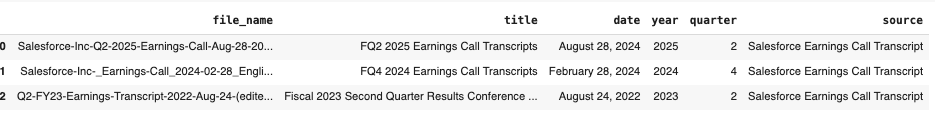

In [ ]:
!pip install pymupdf

In [ ]:
### Authenticate your notebook environment (Colab only)
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()


from google.colab import auth
import os
import re
import fitz  # PyMuPDF
import pandas as pd

In [ ]:
import os
import re
import fitz  # PyMuPDF

def get_document_metadata(pdf_path: str) -> dict:
    """Extract title and date from the first page of a PDF using PyMuPDF."""
    filename = os.path.basename(pdf_path)
    title = "Unknown"
    date = "Unknown"
    year = "Unknown"
    quarter = "Unknown"

    try:
        doc = fitz.open(pdf_path)
        if len(doc) > 0:
            first_page_text = doc[0].get_text()

            # Title patterns (Quarterly report titles)
            title_patterns = [
                r"(Fiscal \d{4} (?:First|Second|Third|Fourth) Quarter Results[^\n]*)",
                r"(Q[1-4] FY\d{2,4} Earnings[^\n]*)",
                r"(FQ[1-4] \d{4} Earnings[^\n]*)"
            ]
            for pattern in title_patterns:
                match = re.search(pattern, first_page_text)
                if match:
                    title = match.group(1).strip()
                    break

            # Date patterns
            date_patterns = [
                r"([A-Z][a-z]+ \d{1,2},? \d{4})",  # e.g. November 30, 2022
                r"(\d{1,2}\s*-\s*\d{1,2}\s*-\s*\d{4})",  # e.g. 08 - 30 - 2023
                r"([A-Z][a-z]+,\s+[A-Z][a-z]+ \d{1,2}, \d{4}\s+\d{1,2}:\d{2}\s+[AP]M\s+GMT)"  # full timestamp
            ]
            for pattern in date_patterns:
                match = re.search(pattern, first_page_text)
                if match:
                    date = match.group(1).strip()
                    break

            # Quarter/year extraction from title
            quarter_match = re.search(
                r"Q([1-4])\s+FY(\d{2,4})|FQ([1-4])\s+(\d{4})|Fiscal\s+(\d{4})\s+(First|Second|Third|Fourth)",
                title
            )
            if quarter_match:
                groups = quarter_match.groups()
                if groups[0] and groups[1]:  # Q1 FY23
                    quarter = groups[0]
                    year = "20" + groups[1] if len(groups[1]) == 2 else groups[1]
                elif groups[2] and groups[3]:  # FQ1 2023
                    quarter = groups[2]
                    year = groups[3]
                elif groups[4] and groups[5]:  # Fiscal 2023 Third
                    year = groups[4]
                    quarter_names = {"First": "1", "Second": "2", "Third": "3", "Fourth": "4"}
                    quarter = quarter_names.get(groups[5], "Unknown")
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")

    return {
        "file_name": filename,
        "title": title,
        "date": date,
        "year": year,
        "quarter": quarter,
        "source": "Salesforce Earnings Call Transcript"
    }

In [ ]:

# Directory containing PDF files
data_dir = "/content/drive/MyDrive/data" # where all PDFs are stored

# Initialize an empty list to store metadata for each PDF
metadata_list = []

# Iterate through all files in the directory
for filename in os.listdir(data_dir):
    if filename.endswith(".pdf"):
        pdf_path = os.path.join(data_dir, filename)
        metadata = get_document_metadata(pdf_path)
        metadata_list.append(metadata)

# Create a Pandas DataFrame from the collected metadata
meta_firstpage = pd.DataFrame(metadata_list)


In [ ]:
# merge embeddings and first page extracted metadata together

import pandas as pd
# Assuming text_metadata_df, image_metadata_df, and meta_firstpage are already defined as pandas DataFrames.

# Merge text_metadata_df and meta_firstpage
merged_text_df = pd.merge(text_metadata_df, meta_firstpage, on='file_name', how='left')

# Merge image_metadata_df and meta_firstpage
merged_image_df = pd.merge(image_metadata_df, meta_firstpage, on='file_name', how='left')


In [ ]:
# @title save merged_text_df, and  merged_image_df as two parquets and upload them to GCS

# Save merged DataFrames as parquet files
merged_text_df.to_parquet("merged_text_data.parquet")
merged_image_df.to_parquet("merged_image_data.parquet")

# Upload parquet files to Google Cloud Storage
!gsutil cp merged_text_data.parquet gs://salesforce-assistant/parquet/
!gsutil cp merged_image_data.parquet gs://salesforce-assistant/parquet/


## turn the embedding + meta df into FAISS

This step will output two FAISS files, all you need to do is to put it in a cloud_run folder see graph below:


In [ ]:
!pip install faiss-cpu
import faiss
import pickle
import os

In [ ]:
# === Process Text Metadata ===
print("📄 Loading text metadata...")
text_embeddings = np.vstack(merged_text_df["text_embedding_chunk"].values).astype("float32")

text_metadata = [
    {
        "file_name": row["file_name"],
        "page_num": row["page_num"],
        "chunk_number": row["chunk_number"],
        "chunk_text": row["chunk_text"],
        "title": row.get("title", "Unknown"),
        "date": row.get("date", "Unknown"),
        "year": row.get("year", "Unknown"),
        "quarter": row.get("quarter", "Unknown")
    }
    for _, row in merged_text_df.iterrows()
]

text_index = faiss.IndexFlatL2(text_embeddings.shape[1])
text_index.add(text_embeddings)

faiss.write_index(text_index, "faiss_export/faiss_text_index.bin")
with open("faiss_export/text_metadata_lookup.pkl", "wb") as f:
    pickle.dump(text_metadata, f)

print("✅ Text index and metadata saved.")

In [ ]:
# === Process Image Metadata with Text Embeddings ===
print("🖼️  Loading image metadata for text-based image search...")

# 🔍 Sanity check: print the shape of embeddings from both sources
print("🔍 Checking embedding dimensions...")
print("  ➤ mm_embedding_from_img_only shape:", np.array(merged_image_df["mm_embedding_from_img_only"].iloc[0]).shape)
print("  ➤ text_embedding_from_image_description shape:", np.array(merged_image_df["text_embedding_from_image_description"].iloc[0]).shape)

# Also check for any nulls in embeddings
if merged_image_df["text_embedding_from_image_description"].isnull().any():
    raise ValueError("❌ Found NULL values in text_embedding_from_image_description column!")

# Validate consistent vector shape across all entries
vector_lengths = merged_image_df["text_embedding_from_image_description"].apply(lambda x: len(x))
print("📏 Unique vector lengths:", vector_lengths.unique())
if len(vector_lengths.unique()) > 1:
    raise ValueError("❌ Inconsistent vector sizes found in image descriptions!")

# Use text_embedding_from_image_description instead of mm_embedding_from_img_only
image_embeddings = np.vstack(merged_image_df["text_embedding_from_image_description"].values).astype("float32")

# Metadata stays the same
image_metadata = [
    {
        "file_name": row["file_name"],
        "page_num": row["page_num"],
        "img_path": f"gs://ifad-lanzi-mrag-food/images/{os.path.basename(row['img_path'])}",
        "img_desc": row["img_desc"],
        "title": row.get("title", "Unknown"),
        "date": row.get("date", "Unknown"),
        "year": row.get("year", "Unknown"),
        "quarter": row.get("quarter", "Unknown")
    }
    for _, row in merged_image_df.iterrows()
]


In [ ]:
# Build FAISS index using validated text embeddings
description_index = faiss.IndexFlatL2(image_embeddings.shape[1])
description_index.add(image_embeddings)

# Save index + metadata
faiss.write_index(description_index, "faiss_export/faiss_image_desc_index.bin")
with open("faiss_export/image_desc_metadata_lookup.pkl", "wb") as f:
    pickle.dump(image_metadata, f)

print("✅ Image description-based FAISS index and metadata saved.")

In [ ]:
# @title upload faiss files to gcs
!gsutil -m cp -r faiss_export gs://salesforce-assistant/faiss/


## Pinecone - for scaling up

In [ ]:
!pip install pinecone-client

In [ ]:
# @title Install and Initialize Pinecone
!pip install -q pinecone-client

import pinecone
import numpy as np
from tqdm import tqdm

# Replace these with your real values
api_key = "your-pinecone-api-key"  # @param {type:"string"}
env = "your-pinecone-environment"  # @param {type:"string"}

pinecone.init(api_key=api_key, environment=env)

In [ ]:
# @title Create Pinecone Indexes
text_index_name = "ifad-text"
image_index_name = "ifad-image"
dimension = 768  # for Gemini embeddings

for name in [text_index_name, image_index_name]:
    if name not in pinecone.list_indexes():
        pinecone.create_index(name, dimension=dimension)
        print(f"✅ Created index: {name}")
    else:
        print(f"✅ Index already exists: {name}")

In [ ]:
# @title Upload `merged_text_df`

# Ensure embedding is float32 list
merged_text_df["text_embedding_chunk"] = merged_text_df["text_embedding_chunk"].apply(lambda x: np.array(x, dtype=np.float32).tolist())

text_vectors = [
    (
        f"text-{i}",
        row["text_embedding_chunk"],
        {
            "file_name": row["file_name"],
            "page_num": row["page_num"],
            "chunk_number": row["chunk_number"],
            "chunk_text": row["chunk_text"],
            "title": row.get("title", "Unknown"),
            "date": row.get("date", "Unknown"),
            "year": row.get("year", "Unknown"),
            "quarter": row.get("quarter", "Unknown"),
        }
    )
    for i, row in merged_text_df.iterrows()
]

text_index = pinecone.Index(text_index_name)
batch_size = 100
for i in tqdm(range(0, len(text_vectors), batch_size)):
    text_index.upsert(vectors=text_vectors[i:i+batch_size])

In [ ]:
# @title Upload `merged_image_df`

# Make sure image embedding is float32 list
merged_image_df["mm_embedding_from_img_only"] = merged_image_df["mm_embedding_from_img_only"].apply(lambda x: np.array(x, dtype=np.float32).tolist())

image_vectors = [
    (
        f"image-{i}",
        row["mm_embedding_from_img_only"],
        {
            "file_name": row["file_name"],
            "page_num": row["page_num"],
            "img_path": row["img_path"],
            "img_desc": row["img_desc"],
        }
    )
    for i, row in merged_image_df.iterrows()
]

image_index = pinecone.Index(image_index_name)
for i in tqdm(range(0, len(image_vectors), batch_size)):
    image_index.upsert(vectors=image_vectors[i:i+batch_size])

## Prompt used in main.py


        instruction = """Task: Answer user questions about Salesforce’s quarterly earnings reports using the provided context (text and images). Your response should be accurate, concise, and clearly grounded in the source material.

                      Instructions:

                      1. **Analyze:** Carefully examine the provided text and images from Salesforce earnings reports.
                      2. **Synthesize:** Integrate insights from both textual and visual data where applicable.
                      3. **Reason:** Identify key information, trends, and logical patterns—especially when the question spans multiple time periods.
                      4. **Respond:** Format your answer using the structure below:

                        * **Question:** [User’s question]
                        * **Answer:** [Direct response to the question]
                        * **Explanation:**
                          - [Bullet-point reasoning steps, such as key phrases found, comparisons made, etc.]
                          - [If applicable, describe how the answer was derived across different documents or pages]
                        * **Source:** [Document name, page number, or image name from which the answer is derived]

                      5. **Meta Questions:** If the question is about the dataset itself (e.g., number of documents or pages), refer to the index or metadata context and cite the system source accordingly.
                      
                      6. **Ambiguity:** If the context is insufficient to answer, respond:
                         **"Not enough context to answer."**
                      """